# 4 Propensity Score

<div style="display: flex; align-items: flex-start;">

  <!-- Texto a la izquierda -->
  <div style="flex: 1; padding-right: 20px; width: 60%">
    <p><strong>Fecha:</strong> 2025-08-09</p>

	1.	Quiero comparar cómo afectan las cámaras de velocidad, pero ahí la pregunta es: ¿contra qué comparo?
	2.	Si solo tomo todas las unidades no tratadas como grupo de control, sé que no es una comparación justa.
        Por definición, algo tenían las unidades tratadas para que les pusieran una cámara. 
        Asumir que se pusieron al azar sería ingenuo: aunque a veces lo parezca, seguro hubo algún criterio detrás.
	3.	Como la asignación no fue aleatoria, necesito encontrar un grupo de control que permita una comparación justa.
	4.	Una comparación es justa cuando comparo peras con peras y manzanas con manzanas.
        Lo que haré es elegir, de todas las unidades no tratadas, solo las manzanas.
	5.	Aquí está lo difícil: hay muchas variables que determinan si una unidad es una manzana.
        El propensity score resume todo eso en un solo número: la probabilidad de que una unidad reciba tratamiento.
	6.	Una vez que tenga las manzanas del grupo no tratado, ese será mi grupo de control.
        Este grupo debe ser muy similar al tratado, y en ese contexto puedo asumir que la asignación fue “casi” aleatoria.
	7.	Esto implica que mis resultados solo aplican a las manzanas, no a las peras.
        Es decir, no puedo generalizar a todas las unidades no tratadas, solo a las que son comparables.
	8.	Por último, debo demostrar que:
    	•	Las distribuciones de las variables en ambos grupos (tratados y control) son similares.
    	•	Hay soporte común en el PS (que existan unidades de control y tratadas con valores que se solapan).
        Si no existe una unidad de control representativa para una tratada, esa tratada se excluye.
  </div>

  <!-- Imagen a la derecha -->
  <div style="flex: 1; width:40%">
    <img src="../data/graphs/razonamiento-propensity-score.jpeg" alt="Diagrama Propensity Score" style="max-width: 100%;">
  </div>

</div>

#### Notas durante la investigación

Las pruebas de hipótesis más comunes para evaluar si las covariables son comparables o no son las siguientes:
1. SMD: Standardized Mean Deviation que nos dice qué tan lejos está la media de las unidades tratadas con respecto a las unidades de control, en relación a sus desviaciones estándar
   - Super importante: la SMD es una medida descriptiva y no una prueba de hipótesis.
   - TODO: entender qué chingados es esto, demostrarlo y cómo se calcula y cómo se interpreta.
2. KS Test: Kolmogorov-Smirnov test es una prueba no paramétrica que compara dos distribuciones de datos para determinar si vienen o no de la misma población o si hay diferencias sistemáticas entre ellas.
   - No asume normalidad de los datos
   - Analiza de forma completa la distribución (no solo media y varianza)
   - Es sensible a diferencias en posición, disperción o forma de la distribución.
   - Hipótesis nula: ambas muestras vienen de la misma distribución => valor-p estadísticamente significativo significa que no vienen de la misma distribución
   - TODO: entender cómo se calcula y cómo se interpreta
3. Chi-Cuadrado: evalua si la diferncia de medias es estadísticamente significativa, sin embargo, sí depende del tamaño de la muestra, por lo que no sé qué tan buena idea sea reportarla para la muestra completa, sobre todo porque hay mucha diferncia entre el número de unidades tratadas y las no tratadas.

In [7]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp
from sklearn.linear_model import LogisticRegression
from typing import Optional, Dict, Any, List, Union, Tuple
import warnings

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")
PATH_DATA = '../data'

In [2]:
features = pd.read_parquet(os.path.join(PATH_DATA, "grid-propensity-score-features.parquet"))

In [3]:
# TODO: entender qué chingados es el standardized mean difference
# Por qué se usa en estos casos y cómo se interpreta
# Hay que ver si puedo demostrar esta madre, porque definitivamente es algo que debería de poder hacer
def smd(treated: np.ndarray, control: np.ndarray) -> float:
    """
    Compute the Standardized Mean Difference (SMD) between two groups.
    
    La SMD sirve para medir el tamaño del desbalance 
    cuando la variable es continua o binaria.

    SMD < 0.1 implica buen balance, y no depende del tamaño de la muestra. 
    
    
    Parameters:
        treated (np.ndarray): Array of values for the treated group
        control (np.ndarray): Array of values for the control group
        
    Returns:
        float: SMD value
    """
    treated = np.asarray(treated, dtype=float)
    control = np.asarray(control, dtype=float)

    # Means
    mean_t = np.mean(treated)
    mean_c = np.mean(control)
    
    # Standard deviations
    sd_t = np.std(treated, ddof=1)
    sd_c = np.std(control, ddof=1)
    
    # Pooled standard deviation
    pooled_sd = np.sqrt((sd_t**2 + sd_c**2) / 2)
    
    # SMD
    if pooled_sd == 0:
        return np.nan  # Avoid division by zero
    
    return (mean_t - mean_c) / pooled_sd

In [5]:
def variance_ratio(
    x_treated,
    x_control,
    ddof: int = 1,
    nan_policy: str = "omit",
    ci_alpha: Optional[float] = None
) -> Dict[str, Any]:
    """
    Calcula la razón de varianzas VR = Var(tratados) / Var(controles).

    Parámetros
    ----------
    x_treated : array-like
        Valores de la covariable en el grupo tratado.
    x_control : array-like
        Valores de la covariable en el grupo de control.
    ddof : int, por defecto 1
        Grados de libertad para la varianza muestral (ddof=1 => varianza muestral).
        Usa ddof=0 si quieres varianza poblacional.
    nan_policy : {"omit", "raise"}, por defecto "omit"
        Si "omit", elimina NaNs antes de calcular; si "raise", lanza error si hay NaNs.
    ci_alpha : float opcional
        Si se especifica (por ejemplo 0.05), devuelve IC del 1-ci_alpha para la razón
        de varianzas usando una aproximación F (supone normalidad).

    Devuelve
    --------
    dict con:
        - "vr": float, razón de varianzas.
        - "var_treated": varianza en tratados.
        - "var_control": varianza en controles.
        - "n_treated", "n_control": tamaños efectivos tras aplicar nan_policy.
        - "ddof": ddof usado.
        - "ci": (lo, hi) si ci_alpha no es None y scipy está disponible.
        - "ci_level": nivel de confianza correspondiente.
        - "ci_error": mensaje si no pudo calcular el IC.

    Notas
    -----
    - Si Var(controles) = 0 y Var(tratados) > 0, la razón es inf.
    - Si ambas varianzas son 0, la razón es NaN (indefinida).
    """
    xt = np.asarray(x_treated, dtype=float)
    xc = np.asarray(x_control, dtype=float)

    if nan_policy not in {"omit", "raise"}:
        raise ValueError("nan_policy debe ser 'omit' o 'raise'.")

    if nan_policy == "omit":
        xt = xt[~np.isnan(xt)]
        xc = xc[~np.isnan(xc)]
    else:
        if np.isnan(xt).any() or np.isnan(xc).any():
            raise ValueError("Hay NaNs en los datos y nan_policy='raise'.")

    n1, n2 = xt.size, xc.size
    if n1 - ddof <= 0 or n2 - ddof <= 0:
        raise ValueError("Tamaños insuficientes para el ddof elegido.")

    var_t = np.var(xt, ddof=ddof)
    var_c = np.var(xc, ddof=ddof)

    if var_c == 0 and var_t == 0:
        vr = float("nan")
    elif var_c == 0:
        vr = float("inf")
    else:
        vr = var_t / var_c

    out = {
        "vr": vr,
        "var_treated": var_t,
        "var_control": var_c,
        "n_treated": n1,
        "n_control": n2,
        "ddof": ddof,
    }

    if ci_alpha is not None:
        try:
            from scipy.stats import f
            df1 = n1 - ddof
            df2 = n2 - ddof
            # IC para sigma_t^2 / sigma_c^2: [ VR / F_{1-α/2}(df1,df2), VR / F_{α/2}(df1,df2) ]
            lo = vr / f.ppf(1 - ci_alpha / 2, df1, df2)
            hi = vr / f.ppf(ci_alpha / 2, df1, df2)
            out["ci"] = (lo, hi)
            out["ci_level"] = 1 - ci_alpha
        except Exception as e:
            out["ci_error"] = f"No se pudo calcular el IC: {e}"

    return out

In [8]:
def add_propensity_score(
    df: pd.DataFrame,
    feature_cols: List[str],
    target_col: str,
    propensity_col: str = "propensity_score",
    numeric_impute: str = "median",
    categorical_impute: str = "most_frequent",
    scale_numeric: bool = True,
    class_weight: Optional[Union[str, dict]] = None,
    C: float = 1.0,
    max_iter: int = 1000,
    random_state: Optional[int] = None,
    return_model: bool = False
) -> Union[pd.DataFrame, Tuple[pd.DataFrame, Pipeline]]:
    """
    Fit logistic regression for treatment assignment and append propensity scores.

    Parameters
    ----------
    df : DataFrame with features X and target y.
    feature_cols : names of X columns to use.
    target_col : name of the binary target column (0/1).
    propensity_col : output column name for the propensity score.
    numeric_impute : imputation strategy for numeric features.
    categorical_impute : imputation strategy for categorical features.
    scale_numeric : whether to standardize numeric features.
    class_weight : pass 'balanced', a dict, or None to LogisticRegression.
    C : inverse regularization strength for LogisticRegression.
    max_iter : max iterations for solver.
    random_state : RNG seed for reproducibility.
    return_model : if True, also return the fitted sklearn Pipeline.

    Returns
    -------
    df_out : original DataFrame with an added propensity_col.
    (df_out, model) if return_model=True
    """

    X = df[feature_cols]
    y = df[target_col]

    # Separate numeric/categorical columns
    numeric_features = X.select_dtypes(include=[np.number, "bool"]).columns.tolist()
    categorical_features = [c for c in feature_cols if c not in numeric_features]

    steps_num = [("imputer", SimpleImputer(strategy=numeric_impute))]
    if scale_numeric:
        steps_num.append(("scaler", StandardScaler()))
    num_pipe = Pipeline(steps=steps_num)

    # OneHotEncoder: use sparse=False for wide compatibility
    cat_pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy=categorical_impute)),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse=False)),
        ]
    )

    transformers = []
    if numeric_features:
        transformers.append(("num", num_pipe, numeric_features))
    if categorical_features:
        transformers.append(("cat", cat_pipe, categorical_features))

    pre = ColumnTransformer(transformers=transformers, remainder="drop")

    clf = LogisticRegression(
        solver="lbfgs",
        max_iter=max_iter,
        C=C,
        class_weight=class_weight,
        random_state=random_state,
    )

    model = Pipeline(steps=[("preprocess", pre), ("logreg", clf)])
    model.fit(X, y)

    ps = model.predict_proba(X)[:, 1]
    df_out = df.copy()
    df_out[propensity_col] = ps

    return (df_out, model) if return_model else df_out

### Features originales

In [9]:
# Voy a imprimir cuántas unidades tratadas hay, sin tratar y en total
treated = features.query('has_camera == 1')
control = features.query('has_camera == 0')
print(f"Unidades totales: {features.shape[0]}")
print(f"Unidades tratadas: {treated.shape[0]}")
print(f"Unidades sin tratar: {control.shape[0]}")

Unidades totales: 19565
Unidades tratadas: 105
Unidades sin tratar: 19460


In [10]:
# Vamos a demostrar que las unidades tratadas y las no tratadas son sistemáticamente distintas, y por lo tanto, no son comparables
# Básicamente tengo que demostrar que vienen de distribuciones distintas. 

# Para demostrar que vienen de distribuciones distintas se pueden hacer las siguientes pruebas dependiendo del tipo de variable.
variables_continuas = [
    "amm", # afluencia media mensual escalada en la estación de metro más cercana
    "distance_to_station", # distancia escalada a la estación de metro más cercana
    "fcs", # accidentes fatales escalados
    "min", # incidentes menores escalados
    "pic", # incidentes con personal injuries escalados
    "total_accidents", # incidentes totales escalados
]

variables_discretas_ordinales = [
    "n_vialidades", # número de vialidades,
    "max_carriles", # número máximo de carriles de las vialidades dentro de la unidad
    "max_nivel", # nivel máximo de las vialidades dentro de la unidad (eg. segundo piso de periférico sería 2)
]

variables_binarias = [
    "both_directions", # si existen o no vialidades de doble sentido dentro de la unidad
    "via_primaria", # si existen o no vías primarias en la unidad
    "via_acc_cont", # si existen o no vías de acceso controlado dentro de la unidad
]

In [11]:
smd_values = []

for variable in variables_continuas + variables_discretas_ordinales + variables_binarias:
    var_smd = smd(
        treated=treated[variable].values,
        control=control[variable].values
    )
    D_statistic, p_value = ks_2samp(treated[variable].values, control[variable].values)

    vr = variance_ratio(
        x_treated=treated[variable].values,
        x_control=control[variable].values
    )
    
    smd_values.append({
        'variable':variable,
        'smd':var_smd,
        # 'tks':{'d_value':D_statistic, 'p_value':p_value},
        'variance_ratio':vr.get('vr')
    })

In [12]:
# Muy bien Mariano, ya tienes la info del SMD y el variance ratio, que es suficiente al inicio para hacer la comparación inicial.
# La tabla de abajo la puedes reportar, y luego armarte el love plot con las diferencias tras hacer el matching.
before_match = pd.DataFrame(smd_values)

### Calcular Propensity Score

In [13]:
lr = LogisticRegression()

x = features.set_index('grid_id').drop(columns=['has_camera']).values
y = features.has_camera.values

lr.fit(X=x, y=y)

probabilites = lr.predict_proba(x)

propensity_score = features.assign(propensity_score = probabilites[:,1])[['grid_id', 'propensity_score', 'has_camera']]

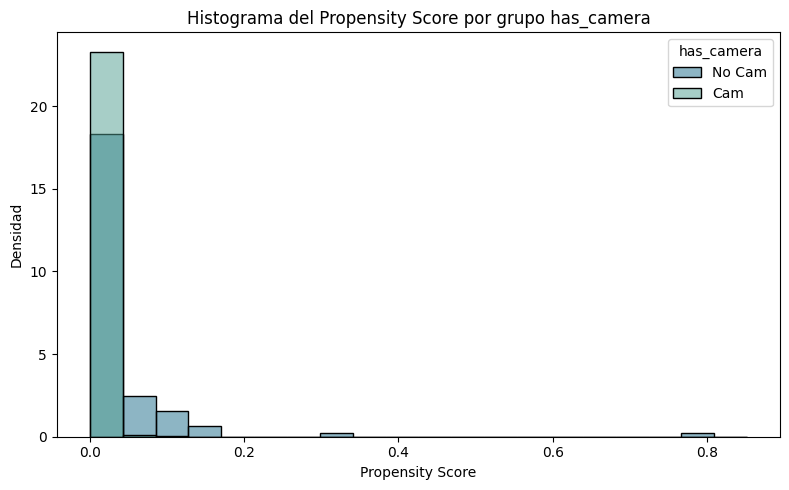

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.histplot(
    data=propensity_score,
    x="propensity_score",
    hue="has_camera",
    bins=20,
    stat="density",        # Para que el área esté normalizada (no cuente frecuencias)
    common_norm=False,      # Cada distribución tendrá un área de 1
    palette="crest",       # Paleta solicitada
    alpha=0.5
)
plt.title("Histograma del Propensity Score por grupo has_camera")
plt.xlabel("Propensity Score")
plt.ylabel("Densidad")
plt.legend(title="has_camera", labels=["No Cam", "Cam"])
plt.tight_layout()
plt.show()

In [15]:
def propensity_score_matching(
    treated_df: pd.DataFrame,
    control_df: pd.DataFrame,
    method: str = "nearest",  # options: "nearest", "caliper"
    n_matches: int = 1,
    replace: bool = True,
    caliper: float = 0.05  # used only if method="caliper"
) -> dict:
    """
    Returns for each treated unit the best matches in the control group,
    based on propensity score distance.

    Parameters
    ----------
    treated_df : pd.DataFrame with columns ["grid_id", "propensity_score"]
    control_df : pd.DataFrame with columns ["grid_id", "propensity_score"]
    method : "nearest" | "caliper"
    n_matches : int, number of matches for each treated unit
    replace : bool, if True, controls can be matched more than once
    caliper : float, maximum allowed distance if using caliper matching

    Returns
    -------
    matches_dict : dict {treated_grid_id: [matched_control_grid_ids]}
    """

    # Pre-extract arrays for speed
    treat_ids = treated_df["grid_id"].values
    treat_scores = treated_df["propensity_score"].values
    ctrl_ids = control_df["grid_id"].values
    ctrl_scores = control_df["propensity_score"].values

    matches = {}

    # To track which controls have been used if no replacement
    available = np.ones(len(ctrl_ids), dtype=bool)

    for i, (tid, tscore) in enumerate(zip(treat_ids, treat_scores)):
        # Distances to all available controls
        distances = np.abs(ctrl_scores - tscore)
        if not replace:
            distances = np.where(available, distances, np.inf)
        if method == "nearest":
            idx = np.argsort(distances)[:n_matches]
            selected_ctrl = ctrl_ids[idx]
            matches[tid] = selected_ctrl.tolist()
            if not replace:
                available[idx] = False  # Mark them as used
        elif method == "caliper":
            # Only controls within caliper
            eligible = (distances <= caliper)
            eligible_idx = np.where(eligible)[0]
            if len(eligible_idx) == 0:
                matches[tid] = []  # No match found
                continue
            # Among eligible, pick n_matches nearest
            eligible_distances = distances[eligible_idx]
            order = np.argsort(eligible_distances)[:n_matches]
            selected_ctrl = ctrl_ids[eligible_idx[order]]
            matches[tid] = selected_ctrl.tolist()
            if not replace:
                available[eligible_idx[order]] = False
        else:
            raise ValueError("method must be 'nearest' or 'caliper'.")

    return matches

In [17]:
matches = propensity_score_matching(
    propensity_score.query('has_camera == 1'), 
    propensity_score.query('has_camera == 0'), 
    n_matches=1, 
    replace=True
)

### Actual fucking analysis

In [18]:
# Una vez que ya tenemos el match, podemos hacer el estudio correspondiente teniendo las unidades de tratamiento y las unidades de control (ya no son "no tratadas")
treated = features.query('has_camera == 1')

matched_ids = pd.DataFrame(matches).values.reshape(-1)
control = features.query('grid_id in @matched_ids')

In [19]:
smd_values = []

for variable in variables_continuas + variables_discretas_ordinales + variables_binarias:
    var_smd = smd(
        treated=treated[variable].values,
        control=control[variable].values
    )
    D_statistic, p_value = ks_2samp(treated[variable].values, control[variable].values)

    vr = variance_ratio(
        x_treated=treated[variable].values,
        x_control=control[variable].values
    )
    
    smd_values.append({
        'variable':variable,
        'smd':var_smd,
        # 'tks':{'d_value':D_statistic, 'p_value':p_value},
        'variance_ratio':vr.get('vr')
    })

In [20]:
after_match = pd.DataFrame(smd_values)

In [22]:
def double_love_plot(
    df_before, 
    df_after, 
    variable_col="variable", 
    smd_col="smd",
    label_before="Before matching", 
    label_after="After matching",
    figsize=(7, 8), 
    threshold=0.1
):

    # Merge both dataframes on variable name
    merged = pd.merge(
        df_before[[variable_col, smd_col]],
        df_after[[variable_col, smd_col]],
        left_on=variable_col, right_on=variable_col,
        suffixes=("_before", "_after")
    )
    # Optional: sort by maximum absolute SMD
    merged = merged.copy()
    merged["max_abs_smd"] = merged[[f"{smd_col}_before", f"{smd_col}_after"]].abs().max(axis=1)
    merged = merged.sort_values("max_abs_smd", ascending=True)
    
    y_labels = merged[variable_col]
    y_pos = range(len(merged))

    plt.figure(figsize=figsize)
    
    # Before matching: triangles
    plt.scatter(merged[f"{smd_col}_before"], y_pos, 
                color=sns.color_palette("crest")[0], 
                s=120, marker="^", label=label_before, alpha=0.9)

    # After matching: circles
    plt.scatter(merged[f"{smd_col}_after"], y_pos, 
                color=sns.color_palette("rocket")[0], 
                s=120, marker="o", label=label_after, alpha=0.9)
    
    plt.axvline(0, color="k", linewidth=1)
    plt.axvline(threshold, color="gray", linestyle="--", lw=1)
    plt.axvline(-threshold, color="gray", linestyle="--", lw=1)
    plt.yticks(y_pos, y_labels)
    plt.xlabel("Standardized Mean Difference (SMD)")
    plt.title("Love Plot: Before and After Matching")
    plt.legend(loc="upper left", frameon=False)
    plt.grid(axis="x", linestyle=":", alpha=0.3)
    plt.tight_layout()
    plt.show()

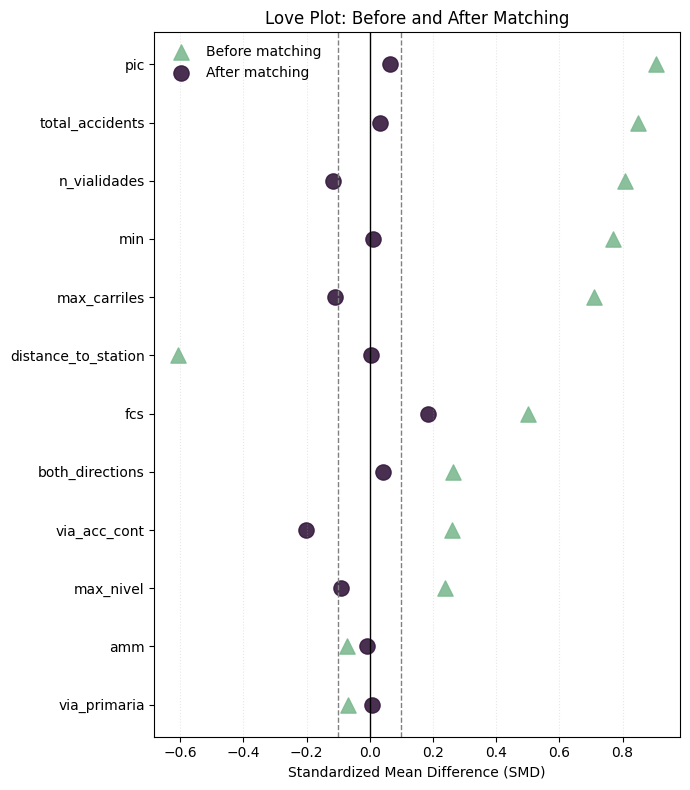

In [23]:
double_love_plot(
    df_before=before_match,
    df_after=after_match,
    variable_col='variable',
    smd_col='smd',
    threshold=.1
)

In [25]:
def calculate_att_general(
    matches, 
    outcome_df, 
    id_col='id', 
    outcome_col='outcome'
):
    """
    Calculate ATT with arbitrary number of matches per treated unit.
    
    matches: dict {treated_id: [matched_control_id1, matched_control_id2, ...]}
    outcome_df: DataFrame with columns [id_col, outcome_col]
    """
    att_list = []
    for treated_id, controls in matches.items():
        # outcome for treated
        y_treated = outcome_df.loc[outcome_df[id_col] == treated_id, outcome_col].values[0]
        # mean outcome for this treated's controls
        y_controls = outcome_df.loc[outcome_df[id_col].isin(controls), outcome_col].mean()
        # if there are no controls (empty list), skip or handle as np.nan
        if np.isnan(y_controls):
            continue
        att_list.append(y_treated - y_controls)
    return np.mean(att_list)

In [26]:
# Mariano, eres un pendejo.
# Estabas usando los accidentes antes del tratamiento!!! Por eso todo te daba efecto positivo, de hecho eso es bueno,
# porque justamente estás comparando unidades similares, esperarías que la diferencia fuera casi cero entre ellas.

# Lo que tienes que hacer es utilizar el promedio de accidentes una vez que se terminó de hacer el estudio.
mean_accidents_at = pd.read_parquet(os.path.join(PATH_DATA, "mean-monthly-accidents-at.parquet"))

In [27]:
calculate_att_general(
    matches=matches,
    outcome_df=mean_accidents_at,
    id_col='grid_id', 
    outcome_col='total'
)*100

np.float64(14.851994851994851)